In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Dataset 4_1

## S/ SMOTE

In [2]:
# -------- 1) Carregar dados --------
# Ajusta o caminho conforme necessário
df4_1 = pd.read_csv(r"C:\Users\HUAWEI\OneDrive\Ambiente de Trabalho\Tese\Final\data4_1.csv")

In [3]:
# -------- 2) Definir target, drops e features --------
target4_1 = "SECClasS_Code_Ss_1_encode"
drop_cols4_1 = ["ElementID", "source", "is_rare_class", "SECClasS_Code_Ss_1"]

features4_1 = [
    "Volume", "Area", "Length", "Height", "Thickness/Width", "Base_offset", "Top_offset",
    "Number_of_Faces", "Bounding_Box_Width", "Bounding_Box_Height", "Bounding_Box_Depth",
    "Centroid_X", "Centroid_Y", "Centroid_Z", "Orientation_Angle", "Curvature",
    "Category_Curtain Panels", "Category_Doors", "Category_Floors", "Category_Roofs",
    "Category_Stairs", "Category_Structural Columns", "Category_Structural Foundations",
    "Category_Structural Framing", "Category_Walls", "Category_Windows",
    "load_bearing_status_binary"
]

In [4]:
# -------- 3) Preparar X e y --------
df_model = df4_1.drop(columns=drop_cols4_1, errors="ignore")
X = df_model[features4_1].copy()
y = df_model[target4_1].copy()

In [5]:
# -------- 4) Train/Test Split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

In [6]:
# -------- 1) SVM sem SMOTE (usa class_weight balanced) --------
svm_no = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", class_weight="balanced", random_state=42)
)
svm_no.fit(X_train, y_train)
pred_no = svm_no.predict(X_test)

acc_no = accuracy_score(y_test, pred_no)
bal_no = balanced_accuracy_score(y_test, pred_no)
f1m_no = f1_score(y_test, pred_no, average="macro")
f1w_no = f1_score(y_test, pred_no, average="weighted")

print("\n=== TESTE — SVM SEM SMOTE ===")
print(f"Accuracy:         {acc_no:.4f}")
print(f"Balanced Accuracy:{bal_no:.4f}")
print(f"F1-macro:         {f1m_no:.4f}")
print(f"F1-weighted:      {f1w_no:.4f}")
print("\nClassification report:")
print(classification_report(y_test, pred_no, digits=4))


=== TESTE — SVM SEM SMOTE ===
Accuracy:         0.8239
Balanced Accuracy:0.9114
F1-macro:         0.6604
F1-weighted:      0.8758

Classification report:
              precision    recall  f1-score   support

           0     0.9948    0.9870    0.9909       771
           1     0.9901    0.7246    0.8368      1525
           2     0.9159    0.9800    0.9469       100
           3     0.7241    1.0000    0.8400        21
           4     0.1250    0.9767    0.2216        43
           5     0.0684    0.8000    0.1260        10

    accuracy                         0.8239      2470
   macro avg     0.6364    0.9114    0.6604      2470
weighted avg     0.9675    0.8239    0.8758      2470



In [7]:
# -------- 2) SVM com SMOTE --------
svm_sm = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", random_state=42))
])
svm_sm.fit(X_train, y_train)
pred_sm = svm_sm.predict(X_test)

acc_sm = accuracy_score(y_test, pred_sm)
bal_sm = balanced_accuracy_score(y_test, pred_sm)
f1m_sm = f1_score(y_test, pred_sm, average="macro")
f1w_sm = f1_score(y_test, pred_sm, average="weighted")

print("\n=== TESTE — SVM COM SMOTE ===")
print(f"Accuracy:         {acc_sm:.4f}")
print(f"Balanced Accuracy:{bal_sm:.4f}")
print(f"F1-macro:         {f1m_sm:.4f}")
print(f"F1-weighted:      {f1w_sm:.4f}")
print("\nClassification report:")
print(classification_report(y_test, pred_sm, digits=4))


=== TESTE — SVM COM SMOTE ===
Accuracy:         0.9085
Balanced Accuracy:0.9140
F1-macro:         0.7107
F1-weighted:      0.9322

Classification report:
              precision    recall  f1-score   support

           0     0.9948    0.9883    0.9915       771
           1     0.9910    0.8623    0.9222      1525
           2     0.8991    0.9800    0.9378       100
           3     0.7241    1.0000    0.8400        21
           4     0.2867    0.9535    0.4409        43
           5     0.0729    0.7000    0.1321        10

    accuracy                         0.9085      2470
   macro avg     0.6614    0.9140    0.7107      2470
weighted avg     0.9702    0.9085    0.9322      2470



Sem SMOTE o SVM “força” muito recall nas classes pequenas (ex.: 4 e 5), mas com precisão baixíssima → muitos falsos positivos.

Com SMOTE sobe bastante o accuracy e o f1_weighted, e melhora a macro, mas ainda fica bem abaixo do RF.

In [8]:
# -------- 3) Validação Cruzada (para robustez) --------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorings = {
    "acc": "accuracy",
    "bal_acc": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

# CV sem SMOTE
cv_no = cross_validate(svm_no, X, y, cv=cv, scoring=scorings, n_jobs=-1)

# CV com SMOTE
cv_sm = cross_validate(svm_sm, X, y, cv=cv, scoring=scorings, n_jobs=-1)

def resumo_cv(nome, res):
    print(f"\n=== CV (5-fold) — {nome} ===")
    for k in scorings.keys():
        vals = res[f"test_{k}"]
        print(f"{k:12s}: {vals.mean():.4f} ± {vals.std():.4f} "
              f"(min={vals.min():.4f}, max={vals.max():.4f})")

resumo_cv("SVM SEM SMOTE", cv_no)
resumo_cv("SVM COM SMOTE", cv_sm)


=== CV (5-fold) — SVM SEM SMOTE ===
acc         : 0.8272 ± 0.0050 (min=0.8211, max=0.8344)
bal_acc     : 0.9202 ± 0.0098 (min=0.9070, max=0.9309)
f1_macro    : 0.6644 ± 0.0034 (min=0.6595, max=0.6680)
f1_weighted : 0.8782 ± 0.0035 (min=0.8755, max=0.8844)

=== CV (5-fold) — SVM COM SMOTE ===
acc         : 0.9166 ± 0.0022 (min=0.9134, max=0.9198)
bal_acc     : 0.9357 ± 0.0175 (min=0.9050, max=0.9550)
f1_macro    : 0.7263 ± 0.0045 (min=0.7205, max=0.7340)
f1_weighted : 0.9377 ± 0.0021 (min=0.9353, max=0.9408)


In [9]:
# --- 3) Função utilitária para Permutation Importance ---
def compute_perm_importance(model, X_test, y_test, feature_names, scoring="balanced_accuracy",
                            n_repeats=10, random_state=42, n_jobs=-1, top_n=15, title_suffix=""):
    """
    Calcula permutation importance no conjunto de TESTE.
    Retorna DataFrame ordenado e mostra gráfico das top N features.
    """
    print(f"\nCalculando Permutation Importance ({title_suffix}) ...")
    result = permutation_importance(
        model, X_test, y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=n_jobs
    )
    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance_mean": result.importances_mean,
        "Importance_std": result.importances_std
    }).sort_values("Importance_mean", ascending=False)

    print(imp_df.head(top_n))

    # Gráfico Top N
    top = imp_df.head(top_n).iloc[::-1]  # inverter para barra horizontal bonita
    plt.figure(figsize=(9, max(5, 0.35*len(top))))
    plt.barh(top["Feature"], top["Importance_mean"], xerr=top["Importance_std"])
    plt.xlabel(f"Permutation importance (média Δ {scoring})")
    plt.title(f"Permutation Importance — SVM RBF {title_suffix}")
    plt.tight_layout()
    plt.show()

    return imp_df



Calculando Permutation Importance ((SEM SMOTE)) ...
                        Feature  Importance_mean  Importance_std
13                   Centroid_Z         0.132250        0.021661
18              Category_Floors         0.129072        0.007063
20              Category_Stairs         0.123436        0.004938
3                        Height         0.060673        0.023688
10           Bounding_Box_Depth         0.057710        0.019024
21  Category_Structural Columns         0.051659        0.013003
23  Category_Structural Framing         0.046762        0.014564
6                    Top_offset         0.043418        0.005747
4               Thickness/Width         0.042800        0.014721
14            Orientation_Angle         0.033366        0.012910
11                   Centroid_X         0.032187        0.018102
26   load_bearing_status_binary         0.025267        0.010624
16      Category_Curtain Panels         0.021632        0.006418
25             Category_Windows      

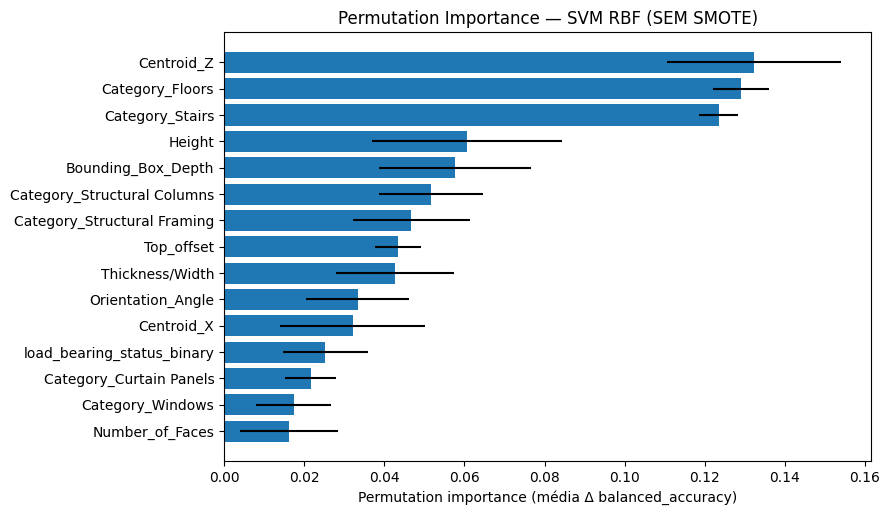


Calculando Permutation Importance ((COM SMOTE)) ...
                        Feature  Importance_mean  Importance_std
13                   Centroid_Z         0.150818        0.027756
4               Thickness/Width         0.132707        0.015820
20              Category_Stairs         0.121887        0.004971
24               Category_Walls         0.118541        0.011647
3                        Height         0.093228        0.029160
17               Category_Doors         0.090098        0.020693
23  Category_Structural Framing         0.067287        0.012835
5                   Base_offset         0.064028        0.008278
11                   Centroid_X         0.053315        0.018899
10           Bounding_Box_Depth         0.048178        0.015558
21  Category_Structural Columns         0.041871        0.015096
6                    Top_offset         0.041543        0.007745
25             Category_Windows         0.039660        0.010139
18              Category_Floors      

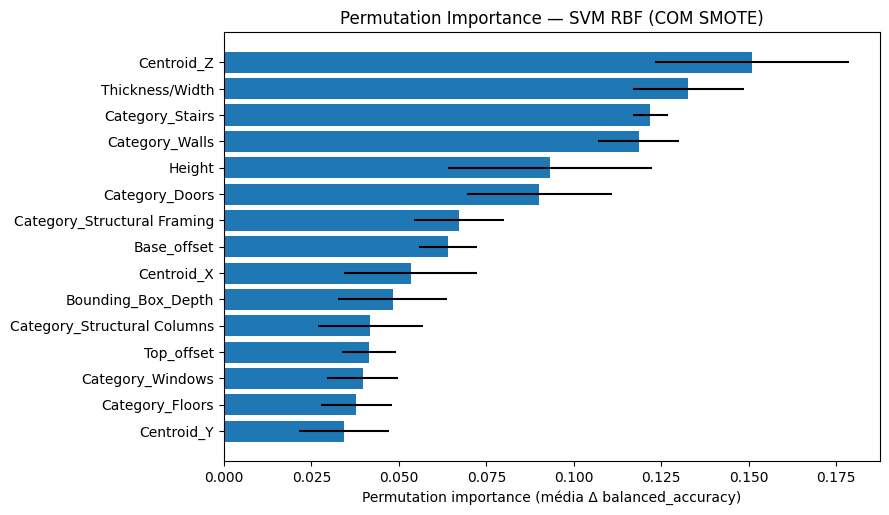

In [10]:
# --- 4) Rodar Permutation Importance (balanced_accuracy) ---
imp_no   = compute_perm_importance(
    svm_no, X_test, y_test, feature_names=X.columns,
    scoring="balanced_accuracy", n_repeats=10, title_suffix="(SEM SMOTE)"
)

imp_sm   = compute_perm_importance(
    svm_sm, X_test, y_test, feature_names=X.columns,
    scoring="balanced_accuracy", n_repeats=10, title_suffix="(COM SMOTE)"
)